In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from analysis_common import (
    load_all_runs, add_hinge_features, NEGOTIATION_MASK,
    SELLER_STRATEGIES, setup_plot_defaults,
)
setup_plot_defaults()

# Restrict to the fixed×fixed notebooks so every seller strategy is stationary
# within a run; this is where per-strategy fingerprints make sense.
df_all = load_all_runs('results_0416b',
                        notebooks=['nb1', 'nb2', 'nb3', 'nb4', 'nb5', 'nb6'])
df_all = add_hinge_features(df_all)
sub_all = df_all[NEGOTIATION_MASK(df_all) & (df_all['round_t'] <= 8)].copy()
sub_all = sub_all.dropna(subset=['s_prev2', 'ds_prev'])
print(f'{len(sub_all):,} Negotiation-region transitions across '
      f'{sub_all["run_idx"].nunique()} runs.')
print(sub_all['supplier_active_strategy_curr'].value_counts().to_frame('n_rows'))

print(sub_all.columns)

[analysis_common] discovered 60 condition files under results_0416b
[analysis_common] built 18274 transition rows from 1320 unique runs
7,843 Negotiation-region transitions across 1320 runs.
                               n_rows
supplier_active_strategy_curr        
boulware_seller                  1319
relational                       1318
anchor_high                      1317
cooperative                      1307
conceder_seller                  1306
tit_for_tat_matcher              1276
Index(['s_t', 'm_t', 's_prev', 'm_prev', 's_prev2', 'm_prev2', 's_prev3',
       'm_prev3', 'v', 'cost', 'market', 'category', 'product', 'quantity',
       'round_t', 'run_idx', 'condition_tag', 'notebook_id', 'model',
       'supplier_id', 'internal_cost', 'buyer_type', 'buyer_active_strategy',
       'supplier_active_strategy_curr', 'supplier_active_strategy_prev',
       'seller_schedule_label', 'seller_is_adaptive', 'template_id', 'region',
       'diff_pos', 'diff_neg', 'ds_prev', 'ds_pos', 'ds

In [8]:
set(sub_all['seller_schedule_label'])

{'anchor_high',
 'boulware_seller',
 'conceder_seller',
 'cooperative',
 'relational',
 'tit_for_tat_matcher'}

In [32]:
df_target = sub_all[(sub_all['seller_schedule_label'] == 'cooperative') & (sub_all['s_t'] < 15)]
df_target.head(5)

,s_t,m_t,s_prev,m_prev,s_prev2,m_prev2,s_prev3,m_prev3,v,cost,...,diff_pos,diff_neg,ds_prev,ds_pos,ds_neg,gap,s_minus_v,delta_s,diffpos_x_sprev,diffneg_x_sprev
3062,2.70,1.40,2.75,1.35,2.80,1.27,NaN,NaN,2.211,1.179,...,0.0,0.811,-0.05,0.0,0.05,1.35,0.539,-0.05,0.0,2.23025
3063,2.65,1.49,2.70,1.40,2.75,1.35,2.80,1.27,2.211,1.179,...,0.0,0.721,-0.05,0.0,0.05,1.21,0.489,-0.05,0.0,1.94670
3064,2.60,1.55,2.65,1.49,2.70,1.40,2.75,1.35,2.211,1.179,...,0.0,0.661,-0.05,0.0,0.05,1.10,0.439,-0.05,0.0,1.75165
3065,2.55,1.58,2.60,1.55,2.65,1.49,2.70,1.40,2.211,1.179,...,0.0,0.631,-0.05,0.0,0.05,1.02,0.389,-0.05,0.0,1.64060
3066,2.52,1.61,2.55,1.58,2.60,1.55,2.65,1.49,2.211,1.179,...,0.0,0.601,-0.05,0.0,0.05,0.94,0.339,-0.03,0.0,1.53255



===== I.I.D. Split Results =====
          model   dataset  n_features  r2_train  r2_val  rmse_train  rmse_val  \
4  OLS_interact  interact           9    0.9991  0.9989      0.1126    0.1146   
3      OLS_lag2      lag2           7    0.9991  0.9989      0.1133    0.1150   
5  OLS_relative  relative           9    0.9991  0.9989      0.1133    0.1150   
2      OLS_more      more           4    0.9988  0.9987      0.1270    0.1219   
1      OLS_core      core           3    0.9988  0.9987      0.1286    0.1223   
0  OLS_baseline  baseline           2    0.7141  0.7103      1.9886    1.8421   

   mae_train  mae_val  
4     0.0515   0.0505  
3     0.0510   0.0507  
5     0.0510   0.0507  
2     0.0605   0.0597  
1     0.0610   0.0598  
0     1.3161   1.2752  

===== Grouped Split Results (no within-run leakage) =====
              model   dataset  n_features  r2_train  r2_val  rmse_train  \
2      OLS_more_grp      more           4    0.9989  0.9986      0.1151   
1      OLS_core_grp  

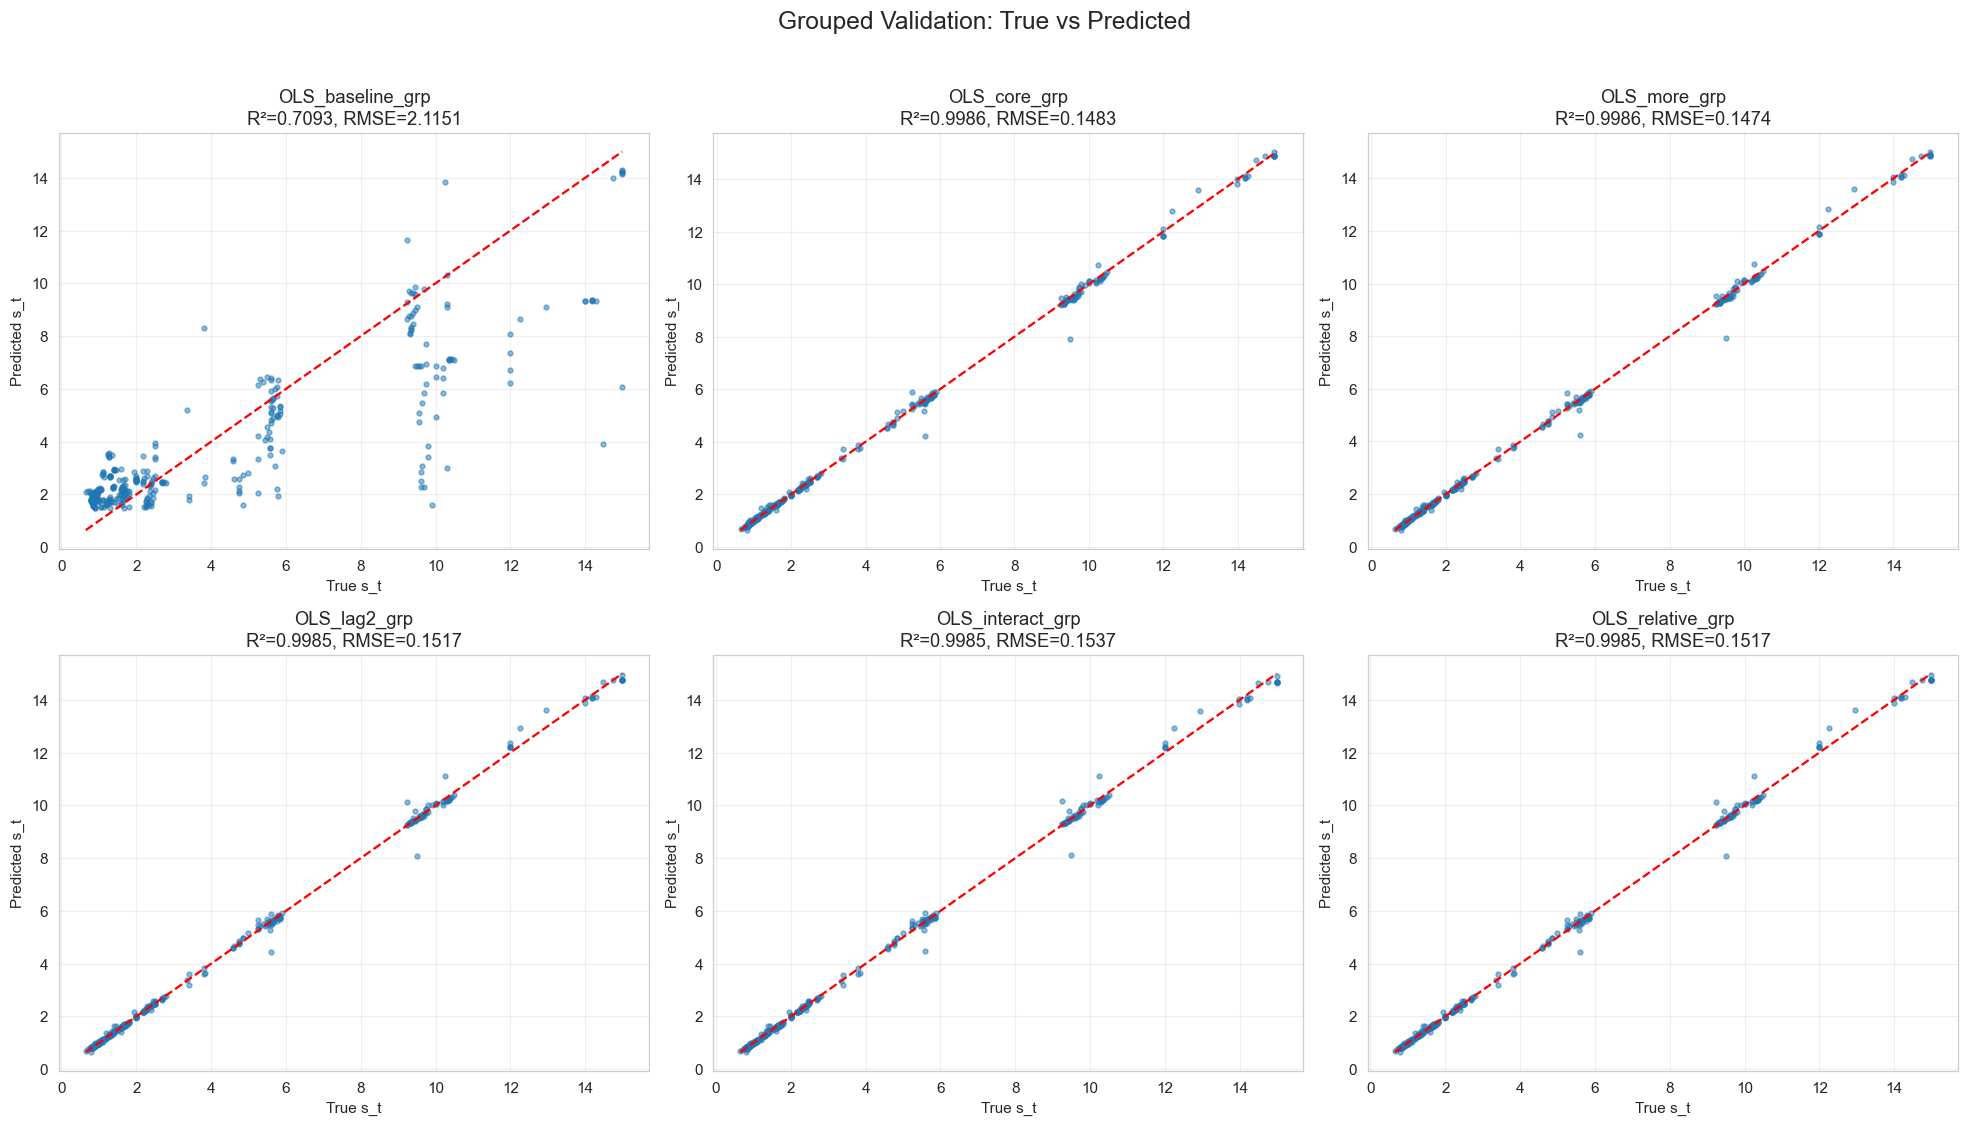

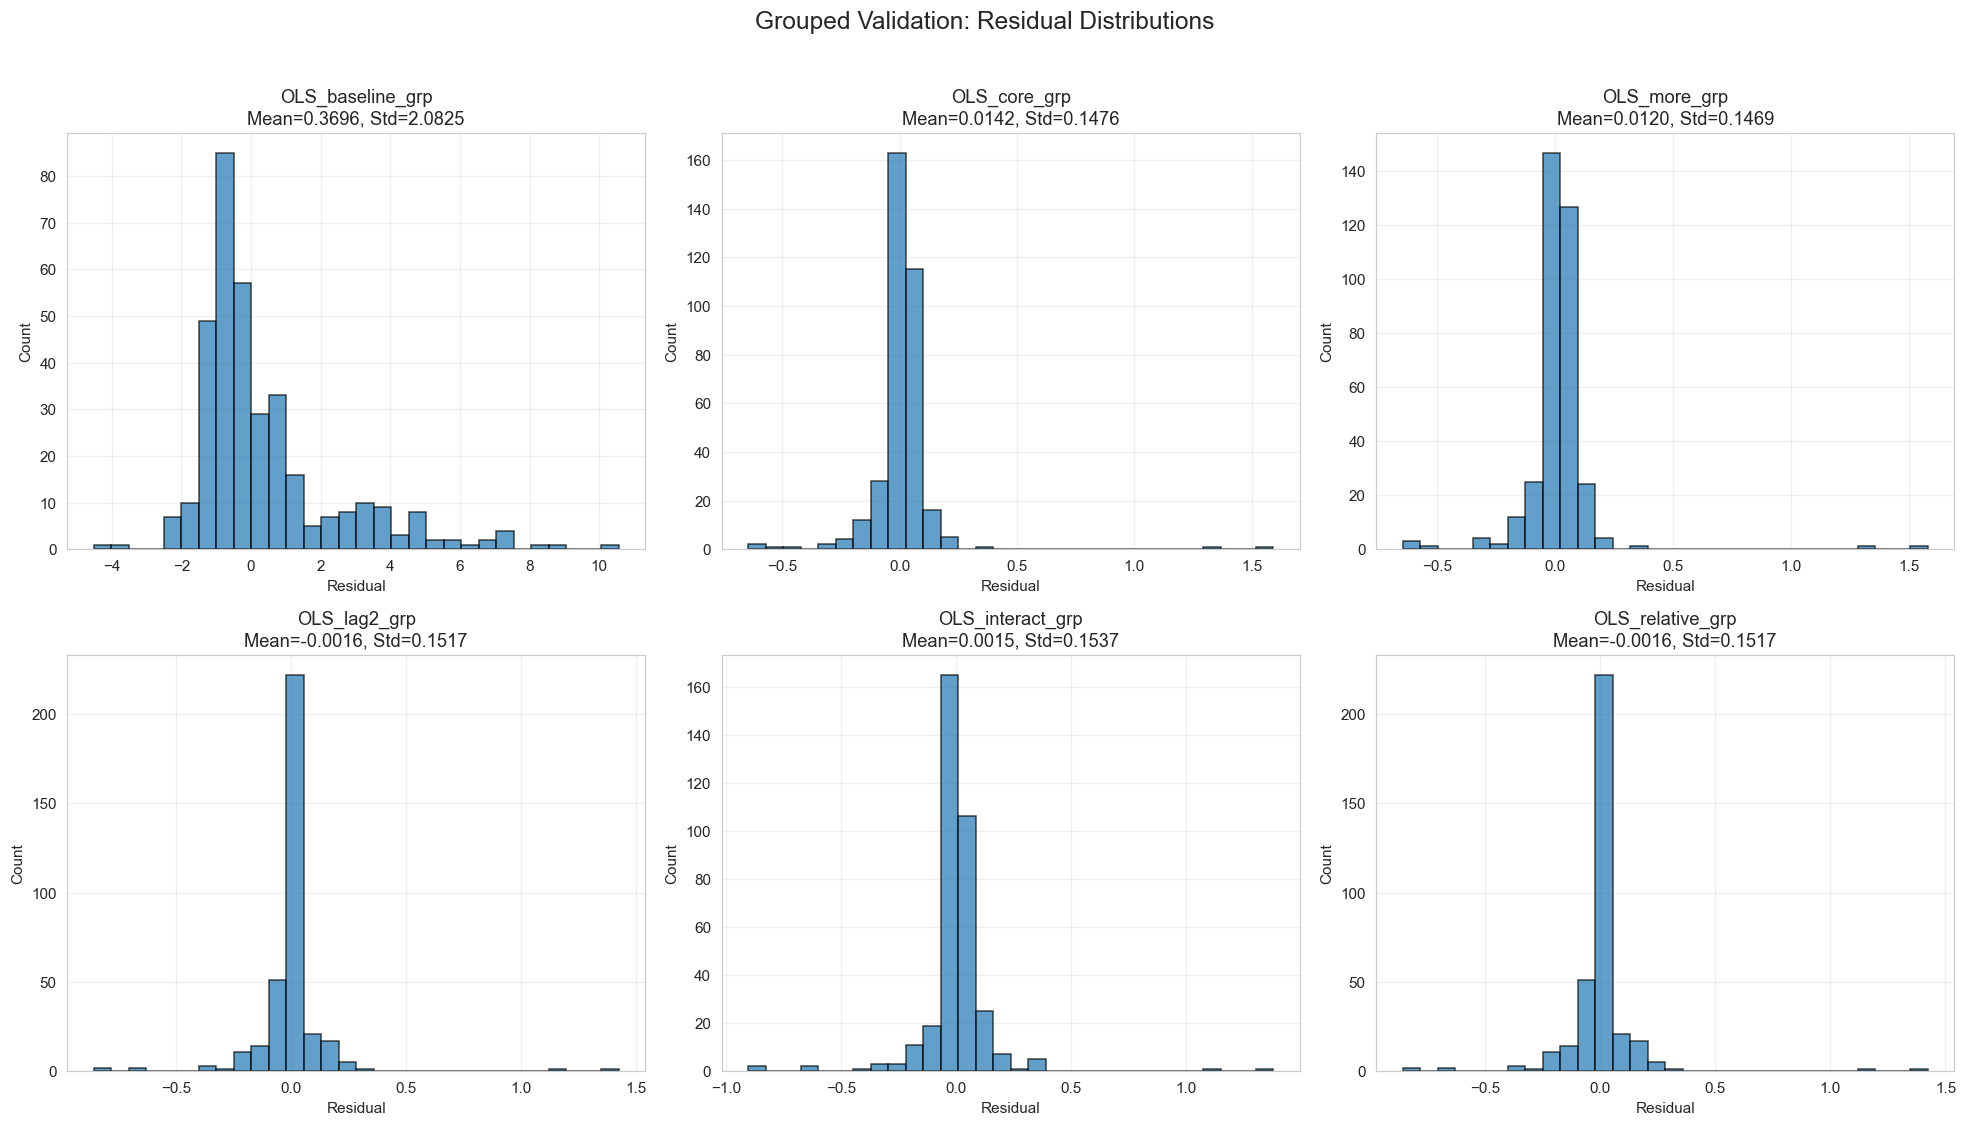

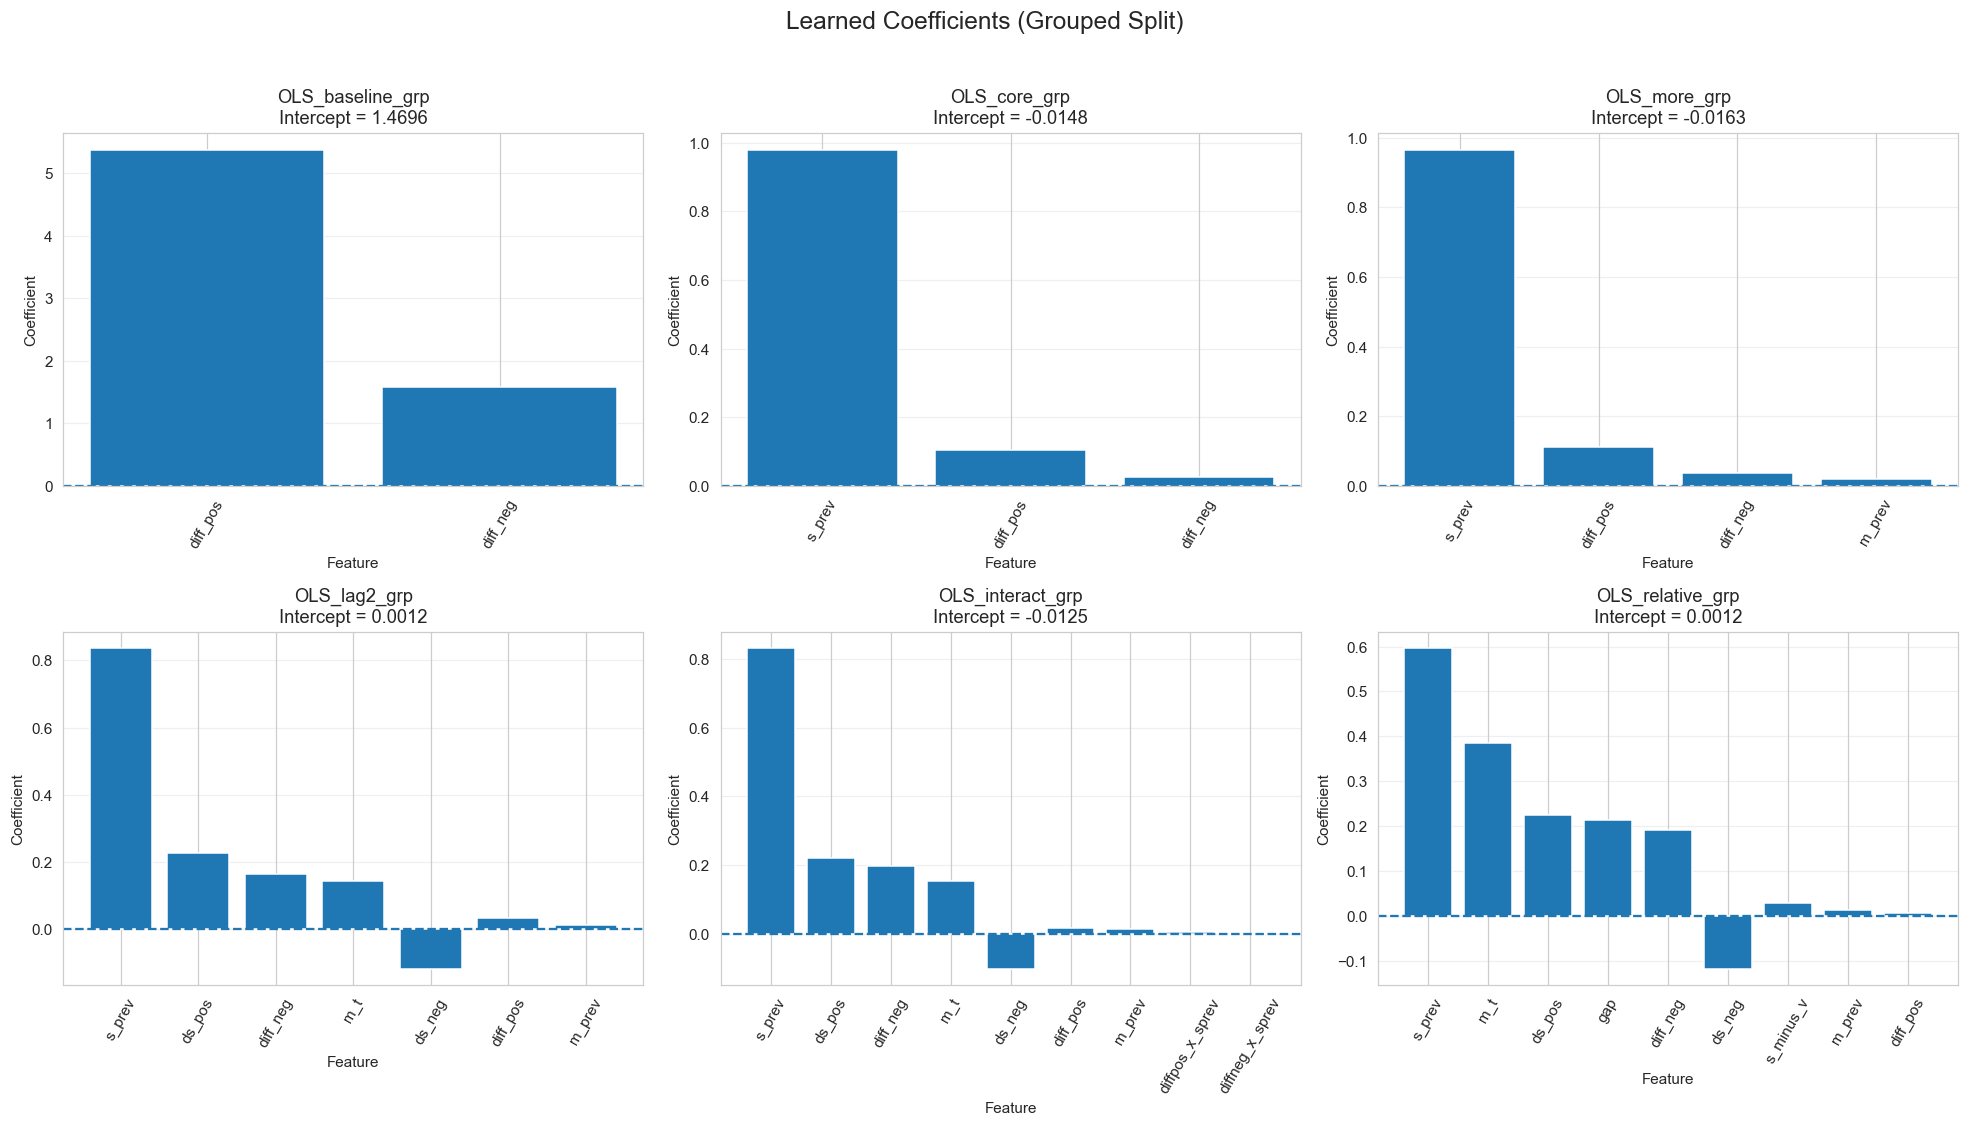

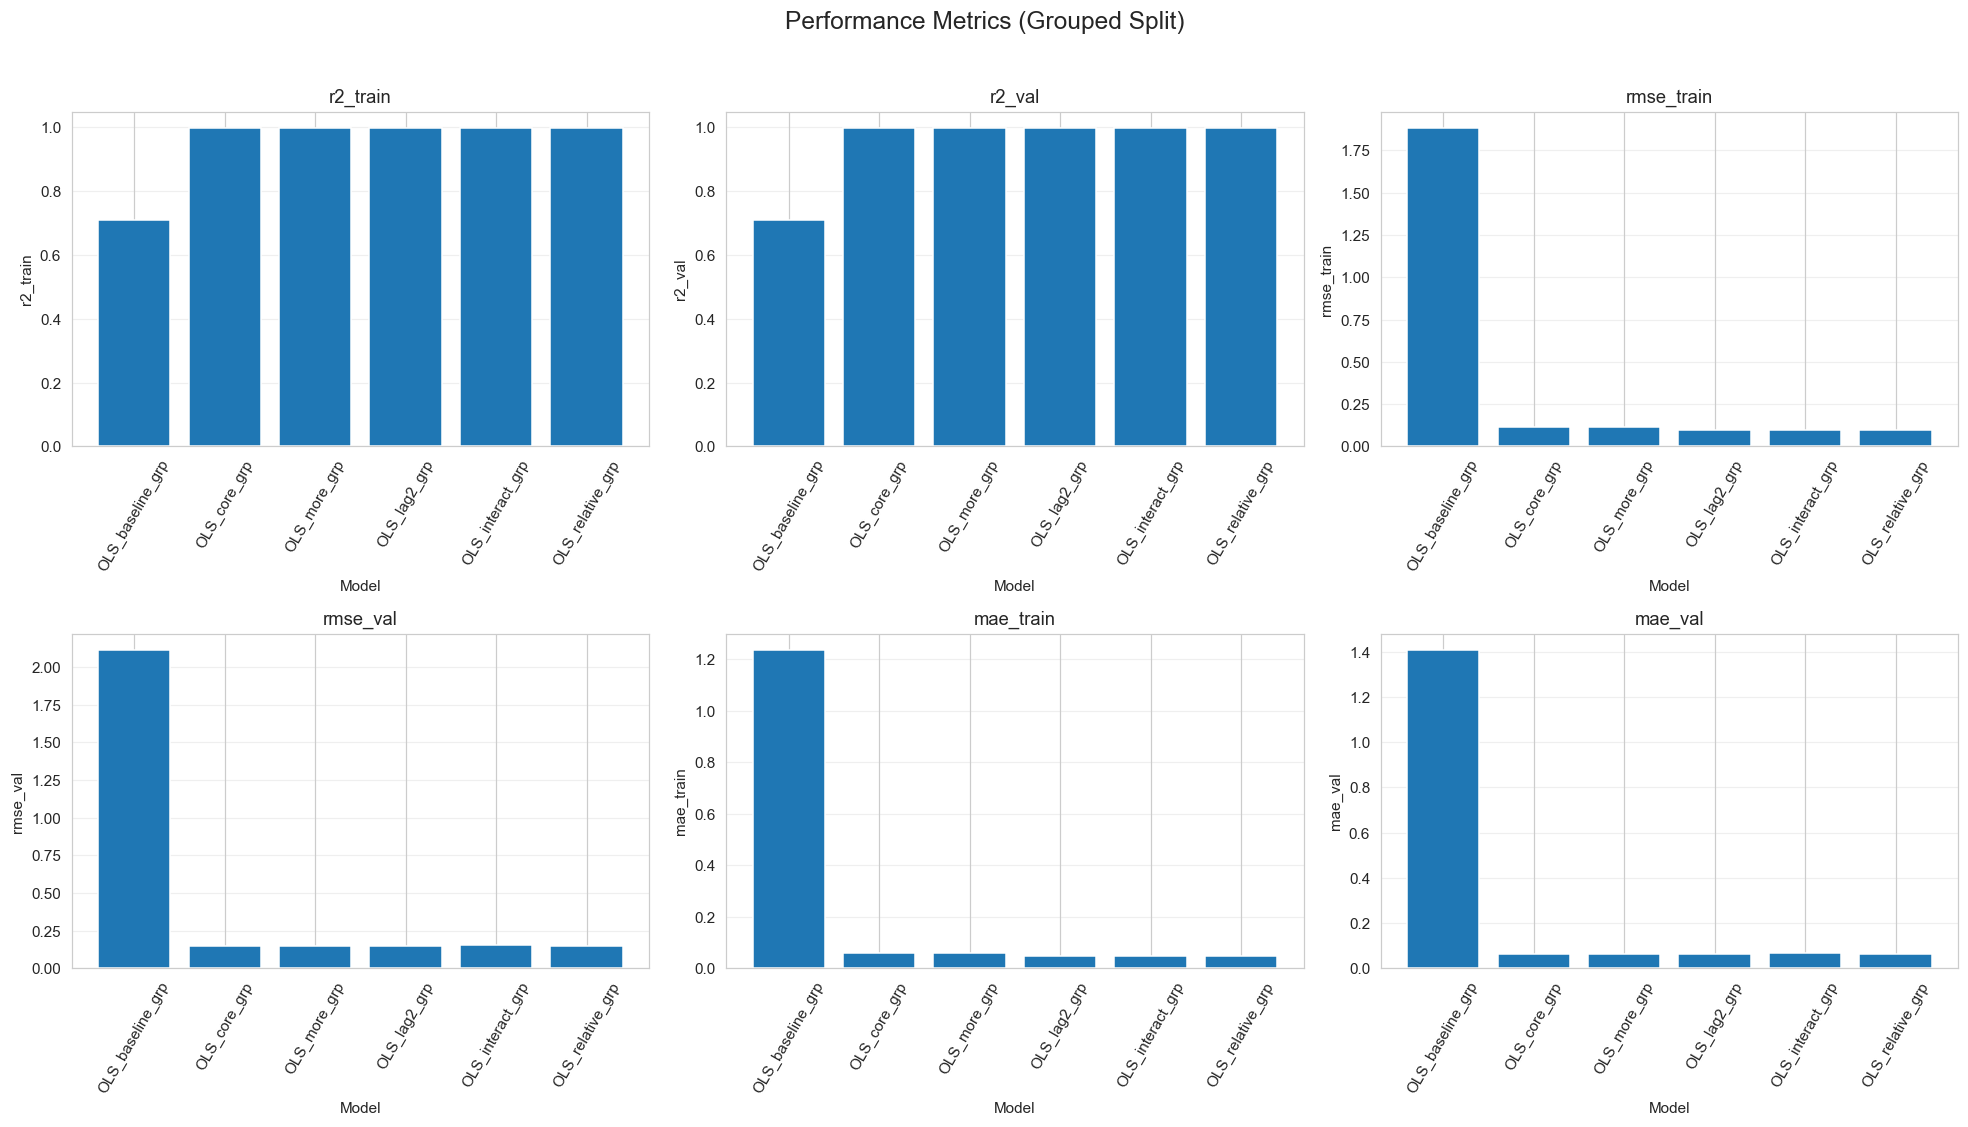


===== Best Grouped Validation Model by R^2 =====
model         OLS_more_grp
dataset               more
n_features               4
r2_train          0.998923
r2_val            0.998587
rmse_train        0.115115
rmse_val          0.147435
mae_train         0.060266
mae_val            0.06462
Name: 2, dtype: object


In [33]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# =========================================================
# Feature engineering
# =========================================================




# =========================================================
# Feature sets
# =========================================================

baseline_features = ['diff_pos', 'diff_neg']

core_features = ['diff_pos', 'diff_neg', 's_prev']

more_features = ['diff_pos', 'diff_neg', 's_prev', 'm_prev']

lag2_features = [
    'diff_pos', 'diff_neg', "m_t", 'ds_pos', 'ds_neg', 's_prev', 'm_prev'
]

# === New extended sets ===

# lag2 + interactions with s_prev
interact_features = lag2_features + [
    'diffpos_x_sprev', 'diffneg_x_sprev',
]

# lag2 + relative position
relative_features = lag2_features + [
    's_minus_v', 'gap',
]

# =========================================================
# Datasets
# =========================================================

def make_dataset(df_src, feature_list, dropna_cols=None):
    """Build X, y, groups from df_src, dropping NaN in dropna_cols."""
    if dropna_cols is None:
        dropna_cols = feature_list
    df_clean = df_src.dropna(subset=dropna_cols).copy()
    X = df_clean[feature_list].values.copy()
    y = df_clean['s_t'].values.copy()
    groups = df_clean['run_idx'].values.copy()
    return X, y, groups


x_baseline, y_baseline, g_baseline = make_dataset(df_target, baseline_features)
x_core, y_core, g_core             = make_dataset(df_target, core_features)
x_more, y_more, g_more             = make_dataset(df_target, more_features)
x_lag2, y_lag2, g_lag2             = make_dataset(df_target, lag2_features,
                                                   dropna_cols=['s_prev2', 'm_prev2'])
x_interact, y_interact, g_interact = make_dataset(df_target, interact_features,
                                                    dropna_cols=['s_prev2', 'm_prev2'])
x_relative, y_relative, g_relative = make_dataset(df_target, relative_features, dropna_cols=['s_prev2', 'm_prev2'])        


datasets = {
    "baseline":  (x_baseline,  y_baseline,  g_baseline,  baseline_features),
    "core":      (x_core,      y_core,      g_core,      core_features),
    "more":      (x_more,      y_more,      g_more,      more_features),
    "lag2":      (x_lag2,      y_lag2,      g_lag2,      lag2_features),
    "interact":  (x_interact,  y_interact,  g_interact,  interact_features),
    "relative":  (x_relative,  y_relative,  g_relative,  relative_features),
}


# =========================================================
# 1. Evaluation helpers
# =========================================================

def evaluate_linear_model(X, y, feature_names, model_name, test_size=0.3, random_state=42):
    """Standard i.i.d. split."""
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return {
        "model_name": model_name, "feature_names": feature_names,
        "X_train": X_train, "X_val": X_val,
        "y_train": y_train, "y_val": y_val,
        "y_pred_train": y_pred_train, "y_pred_val": y_pred_val,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_val": r2_score(y_val, y_pred_val),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_val": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_val": mean_absolute_error(y_val, y_pred_val),
        "intercept": model.intercept_, "coef": model.coef_, "model_obj": model,
    }


def evaluate_linear_model_grouped(X, y, groups, feature_names, model_name,
                                   test_size=0.3, random_state=42):
    """Group-aware split: entire run_idx in train or val, no leakage."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, val_idx = next(gss.split(X, y, groups))
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    return {
        "model_name": model_name, "feature_names": feature_names,
        "X_train": X_train, "X_val": X_val,
        "y_train": y_train, "y_val": y_val,
        "y_pred_train": y_pred_train, "y_pred_val": y_pred_val,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_val": r2_score(y_val, y_pred_val),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_val": np.sqrt(mean_squared_error(y_val, y_pred_val)),
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "mae_val": mean_absolute_error(y_val, y_pred_val),
        "intercept": model.intercept_, "coef": model.coef_, "model_obj": model,
    }


# =========================================================
# 2. Run experiments (both i.i.d. and grouped)
# =========================================================

all_results_iid = []
all_results_grouped = []

for dataset_name, (X, y, groups, feats) in datasets.items():
    # i.i.d. split
    r_iid = evaluate_linear_model(
        X=X, y=y, feature_names=feats,
        model_name=f"OLS_{dataset_name}",
        test_size=0.3, random_state=42
    )
    r_iid["dataset_name"] = dataset_name
    all_results_iid.append(r_iid)

    # grouped split
    r_grp = evaluate_linear_model_grouped(
        X=X, y=y, groups=groups, feature_names=feats,
        model_name=f"OLS_{dataset_name}_grp",
        test_size=0.3, random_state=42
    )
    r_grp["dataset_name"] = dataset_name
    all_results_grouped.append(r_grp)


# =========================================================
# 3. Summary tables
# =========================================================

def make_results_table(results_list):
    return pd.DataFrame([
        {
            "model": r["model_name"], "dataset": r["dataset_name"],
            "n_features": len(r["feature_names"]),
            "r2_train": r["r2_train"], "r2_val": r["r2_val"],
            "rmse_train": r["rmse_train"], "rmse_val": r["rmse_val"],
            "mae_train": r["mae_train"], "mae_val": r["mae_val"],
        }
        for r in results_list
    ])

results_iid = make_results_table(all_results_iid)
results_grouped = make_results_table(all_results_grouped)

print("\n===== I.I.D. Split Results =====")
print(results_iid.sort_values(by="r2_val", ascending=False).round(4))

print("\n===== Grouped Split Results (no within-run leakage) =====")
print(results_grouped.sort_values(by="r2_val", ascending=False).round(4))


# =========================================================
# 4. Learned parameter table (for i.i.d. results)
# =========================================================

param_rows = []
for r in all_results_iid:
    param_rows.append({"model": r["model_name"], "feature": "INTERCEPT",
                        "coefficient": r["intercept"]})
    for feat, coef in zip(r["feature_names"], r["coef"]):
        param_rows.append({"model": r["model_name"], "feature": feat,
                            "coefficient": coef})

linear_params_table = pd.DataFrame(param_rows)
print("\n===== Learned Parameters (I.I.D.) =====")
print(linear_params_table.round(6))


# =========================================================
# 5–9: Plots (using grouped results for honest evaluation)
# =========================================================

all_results = all_results_grouped  # plot the grouped version
results_table = results_grouped

n_models = len(all_results)
ncols = 3
nrows = int(np.ceil(n_models / ncols))

# --- Predicted vs True ---
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, all_results):
    y_val = r["y_val"]; y_pred = r["y_pred_val"]
    ax.scatter(y_val, y_pred, alpha=0.5, s=10)
    lo = min(y_val.min(), y_pred.min()); hi = max(y_val.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_xlabel("True s_t"); ax.set_ylabel("Predicted s_t")
    ax.set_title(f"{r['model_name']}\nR²={r['r2_val']:.4f}, RMSE={r['rmse_val']:.4f}")
    ax.grid(alpha=0.3)
for j in range(len(all_results), len(axes)): axes[j].axis("off")
fig.suptitle("Grouped Validation: True vs Predicted", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Residual histograms ---
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, all_results):
    residuals = r["y_val"] - r["y_pred_val"]
    ax.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
    ax.set_xlabel("Residual"); ax.set_ylabel("Count")
    ax.set_title(f"{r['model_name']}\nMean={np.mean(residuals):.4f}, Std={np.std(residuals):.4f}")
    ax.grid(alpha=0.3)
for j in range(len(all_results), len(axes)): axes[j].axis("off")
fig.suptitle("Grouped Validation: Residual Distributions", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Coefficient bars ---
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, all_results):
    coef_df = pd.DataFrame({"feature": r["feature_names"], "coefficient": r["coef"]})
    coef_df = coef_df.sort_values("coefficient", key=lambda s: np.abs(s), ascending=False)
    ax.bar(coef_df["feature"], coef_df["coefficient"])
    ax.axhline(0, linestyle='--')
    ax.set_xlabel("Feature"); ax.set_ylabel("Coefficient")
    ax.set_title(f"{r['model_name']}\nIntercept = {r['intercept']:.4f}")
    ax.tick_params(axis='x', rotation=60); ax.grid(axis='y', alpha=0.3)
for j in range(len(all_results), len(axes)): axes[j].axis("off")
fig.suptitle("Learned Coefficients (Grouped Split)", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Metric comparison ---
metric_names = ["r2_train", "r2_val", "rmse_train", "rmse_val", "mae_train", "mae_val"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
plot_df = results_table.copy()
for ax, metric in zip(axes, metric_names):
    bars = ax.bar(plot_df["model"], plot_df[metric])
    ax.set_title(metric); ax.set_xlabel("Model"); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=60); ax.grid(axis='y', alpha=0.3)
fig.suptitle("Performance Metrics (Grouped Split)", fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

# --- Best model ---
best_idx = results_table["r2_val"].idxmax()
print("\n===== Best Grouped Validation Model by R^2 =====")
print(results_table.loc[best_idx])